# Convolutional layer

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import PIL
import numpy as np

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt

In [4]:
image = PIL.Image.open('building.jpg')
image = image.resize((120, 180))

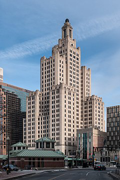

In [5]:
image

In [6]:
image = transforms.ToTensor()(image)
image = image.view(1, image.size(0), image.size(1), image.size(2))

In [54]:
image.size()

torch.Size([1, 3, 180, 120])

# Convolution layer and Pooling layer
https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

In [7]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5) # Unlike with linear layers, image size is not important! It just needs to be larger than kernel size

In [8]:
conv_layer.weight.size() # 16 filters, operating on 5x5 patches of 3 channels (RGB)

torch.Size([16, 3, 5, 5])

### Input to a convolutional layer has shape (BATCH_SIZE, N_CHANNELS, HEIGHT, WIDTH)
### E.g. First layer: (16, 3, 32, 32) - 16 RGB images 32x32 pixels

In [9]:
image.size()

torch.Size([1, 3, 180, 120])

In [10]:
output = conv_layer(image)

In [11]:
output.size() # Feature map - 16 channels, reduced size because no convolution on image edges (180x120 => 176x116)

torch.Size([1, 16, 176, 116])

In [12]:
# We can stack another layer
conv_layer_2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)

In [13]:
output_2 = conv_layer_2(output)

In [14]:
output_2.shape # 32 channels

torch.Size([1, 32, 174, 114])

In [15]:
# We can reduce feature map size with a MaxPool layer
pooling_layer = nn.MaxPool2d(kernel_size=2, stride=2)

In [16]:
output_pool = pooling_layer(output_2)

In [17]:
output_pool.size() # the feature map spatial size is halved

torch.Size([1, 32, 87, 57])

In [18]:
# We can add padding to the image before convolution to keep the feature map size the same
conv_layer_3 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)

In [19]:
output_3 = conv_layer_3(output_pool)

In [20]:
output_3.size()

torch.Size([1, 32, 87, 57])

# Example: fixed filters set manually

In [31]:
conv_layer = nn.Conv2d(in_channels=3, out_channels=4, kernel_size=3)

In [32]:
conv_layer.weight.size() # 4 filters, 3x3 on 3 channel images

torch.Size([4, 3, 3, 3])

In [33]:
#e.g. first filter: 3x3x3 matrix
conv_layer.weight[0]

tensor([[[ 0.0557,  0.1024, -0.0948],
         [ 0.1233,  0.1887,  0.0584],
         [ 0.1069, -0.0916,  0.0069]],

        [[ 0.1503, -0.1666,  0.0115],
         [ 0.0974,  0.0165, -0.0327],
         [ 0.0393,  0.0179, -0.0416]],

        [[ 0.1662,  0.0249,  0.0235],
         [-0.1026, -0.0807,  0.1030],
         [-0.0727, -0.0987,  0.0007]]], grad_fn=<SelectBackward0>)

In [34]:
conv_layer.weight[0].shape

torch.Size([3, 3, 3])

In [35]:
 torch.tensor(filter1).shape

torch.Size([3, 3])

In [36]:
# identity filter
filter1 = np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 0, 0]])

# smoothing filter - mean of surrounding pixels
filter2 = np.array([[1/9, 1/9, 1/9],
                    [1/9, 1/9, 1/9],
                    [1/9, 1/9, 1/9]])

# edge detection filter - 0 for flat areas
filter3 = np.array([[-1, -1, -1],
                    [-1,  8,  -1],
                    [-1, -1, -1]])

In [40]:
with torch.no_grad():
    conv_layer.weight[0][0] = torch.tensor(filter1)
    conv_layer.weight[0][1] = torch.tensor(filter2)
    conv_layer.weight[0][2] = torch.tensor(filter3)

In [41]:
conv_layer.weight[0]

tensor([[[ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        [[ 0.1111,  0.1111,  0.1111],
         [ 0.1111,  0.1111,  0.1111],
         [ 0.1111,  0.1111,  0.1111]],

        [[-1.0000, -1.0000, -1.0000],
         [-1.0000,  8.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000]]], grad_fn=<SelectBackward0>)

In [48]:
#conv_layer.weight

In [49]:
out = conv_layer(image)

In [50]:
out.size()

torch.Size([1, 4, 178, 118])

In [51]:
out = out.detach().cpu().numpy()[0]

In [52]:
out.shape # 4 feature maps (image after convolution)

(4, 178, 118)

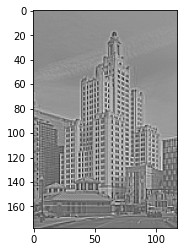

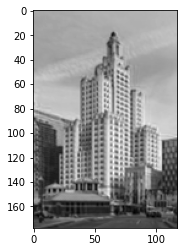

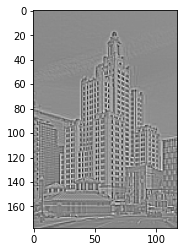

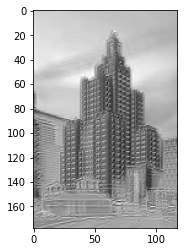

In [53]:
for i in range(len(out)):
    plt.figure()
    plt.imshow(out[i], cmap='gray')